# 01. Разведочный анализ данных (EDA)
## NEU Surface Defect Database

Цель: изучить структуру данных, распределение классов, визуализировать примеры.

In [1]:
import sys
sys.path.insert(0, '..')

from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from PIL import Image
import xml.etree.ElementTree as ET

from src.data.dataset import SteelDataset, parse_voc_xml, CLASS_NAMES, CLASS_TO_IDX

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

### 1. Загрузка данных

In [2]:
train_dataset = SteelDataset(root_dir='../data/train', is_train=False)
val_dataset = SteelDataset(root_dir='../data/validation', is_train=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Total samples: {len(train_dataset) + len(val_dataset)}")

Train samples: 1440
Validation samples: 360
Total samples: 1800


### 2. Распределение классов

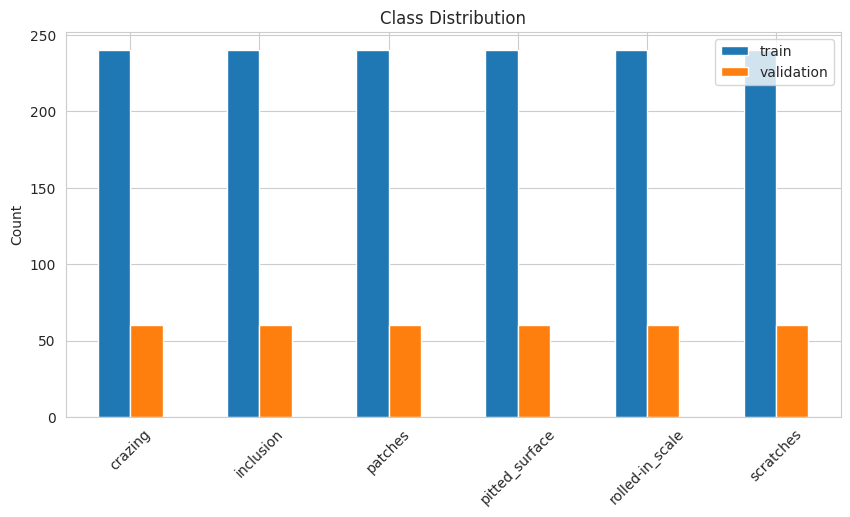

                 train  validation
crazing            240          60
inclusion          240          60
patches            240          60
pitted_surface     240          60
rolled-in_scale    240          60
scratches          240          60


In [3]:
def class_distribution(dataset, name):
    labels = [label for _, label in dataset.samples]
    counts = pd.Series(labels).value_counts().sort_index()
    counts.index = [CLASS_NAMES[i] for i in counts.index]
    return counts

train_counts = class_distribution(train_dataset, 'train')
val_counts = class_distribution(val_dataset, 'val')

df_dist = pd.DataFrame({'train': train_counts, 'validation': val_counts})
df_dist.plot(kind='bar', figsize=(10, 5))
plt.title('Class Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()
print(df_dist)

### 3. Визуализация примеров

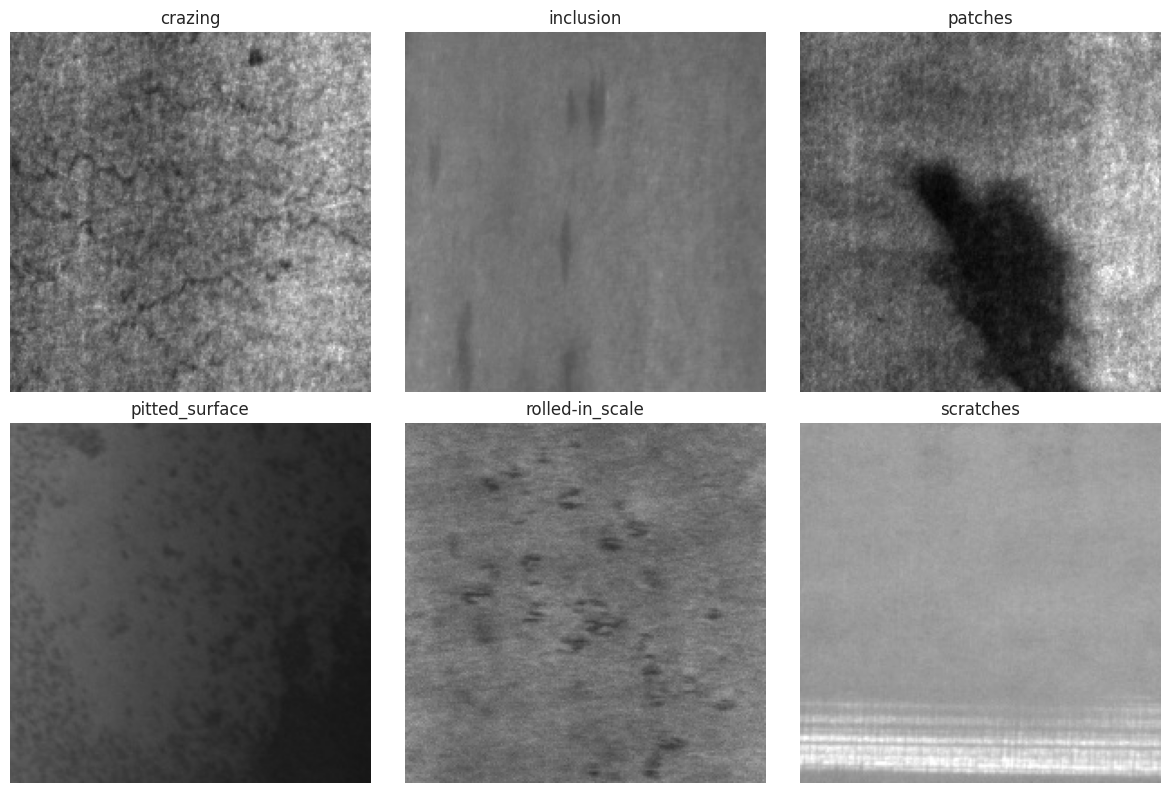

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for i, class_name in enumerate(CLASS_NAMES):
    class_indices = [j for j, (_, label) in enumerate(train_dataset.samples) if label == i]
    idx = np.random.choice(class_indices)
    img_path, _ = train_dataset.samples[idx]
    img = Image.open(img_path).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(f"{class_name}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### 4. Анализ аннотаций (bounding boxes)

In [5]:
import glob

annot_files = sorted(glob.glob('../data/train/annotations/*.xml'))
print(f"Total annotations: {len(annot_files)}")

bbox_data = []
for f in annot_files[:200]:
    objs = parse_voc_xml(f)
    for obj in objs:
        bbox_data.append({
            'class': obj['name'],
            'xmin': obj['xmin'],
            'ymin': obj['ymin'],
            'xmax': obj['xmax'],
            'ymax': obj['ymax'],
            'width': obj['xmax'] - obj['xmin'],
            'height': obj['ymax'] - obj['ymin'],
            'area': (obj['xmax'] - obj['xmin']) * (obj['ymax'] - obj['ymin']),
        })

df_bbox = pd.DataFrame(bbox_data)
print(f"Objects: {len(df_bbox)}")
print(f"Avg box area: {df_bbox['area'].mean():.0f} px²")
print(f"Avg objects per image: {len(df_bbox) / 200:.2f}")

Total annotations: 1439
Objects: 443
Avg box area: 8694 px²
Avg objects per image: 2.21


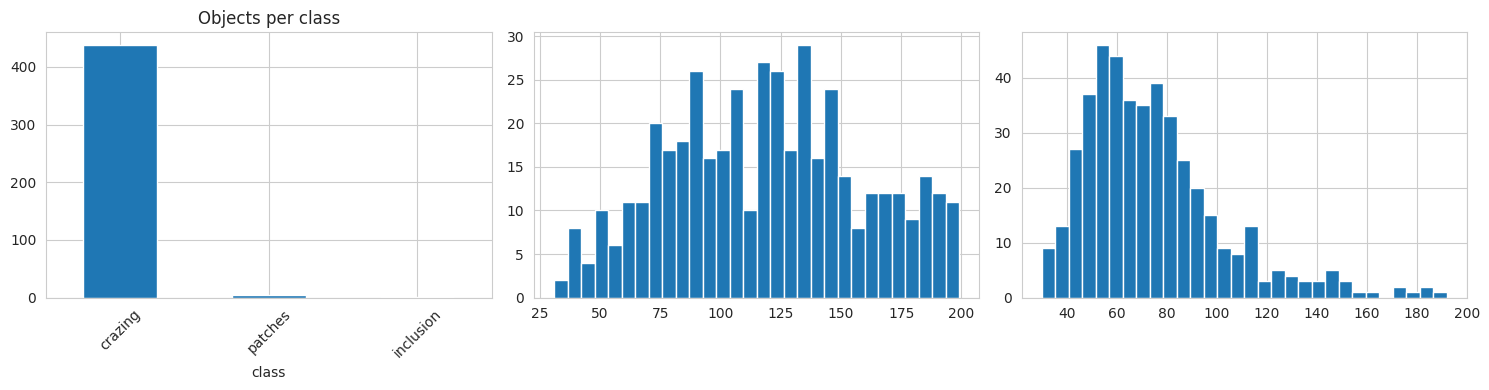

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df_bbox['class'].value_counts().plot(kind='bar', ax=axes[0], title='Objects per class')
axes[0].tick_params(axis='x', rotation=45)
df_bbox['width'].hist(bins=30, ax=axes[1])
df_bbox['height'].hist(bins=30, ax=axes[2])
plt.tight_layout()
plt.show()

### 5. Выводы

- Данные сбалансированы: 240 изображений на класс в train, 60 в val
- Изображения 200×200, grayscale
- В каждом изображении может быть несколько объектов разных классов
- Задача: классификация всего изображения по преобладающему дефекту